**TASK 1**

**Discuss the concept of hooks in React. Explain how they differ from class component lifecycle methods. Also, provide an example**

What are hooks in react?
* Hooks are special functions introduced in React 16.8 that allow you to use state, lifecycle features, and other React capabilities in functional components.

  Before Hooks:

  * State only in class components
  * Lifecycle methods only in class components

  After Hooks:

  * State in functional components
  * Lifecycle behavior in functional components
  * Cleaner, shorter, and reusable logic

  Common Hooks:

  * useState() → state management
  * useEffect() → lifecycle side effects
  * useContext() → context usage
  * useRef() → DOM references
  * useMemo(), useCallback() → performance

Why Hooks Were Introduced?

*  Problems with class components:

   * this keyword confusion
   * Long lifecycle methods
   * Logic scattered across multiple methods
   * Hard to reuse state logic

*  Hooks solve this by:

   * Removing this
   * Grouping related logic together
   * Making code reusable and readable

* Class Component Lifecycle Methods

  Class components use lifecycle methods like:

    |   Lifecycle   |   Phase	Method        |
    |---------------|-----------------------|
    |Mounting	      | componentDidMount()   |
    |Updating	      |componentDidUpdate()   |
    |Unmounting	    | componentWillUnmount()|
   

 ```
  class Counter extends React.Component {
    componentDidMount() {
      console.log("Component Mounted");
    }

    componentDidUpdate() {
      console.log("Component Updated");
    }

    componentWillUnmount() {
      console.log("Component Unmounted");
    }

    render() {
      return <h1>Hello</h1>;
    }
  }

  ```

* Hooks vs Class Lifecycle Methods

  useEffect() replaces lifecycle methods

  | Class Lifecycle      | Hook Equivalent                      |
  | -------------------- | ------------------------------------ |
  | `componentDidMount()`    | `useEffect(() => {}, [])`            |
  | `componentDidUpdate()`   | `useEffect(() => {}, [deps])`        |
  | `componentWillUnmount()` | `return () => {}` inside `useEffect` |


 ```
  import { useState, useEffect } from "react";

  function Counter() {
    const [count, setCount] = useState(0);

    // Runs on mount & update
    useEffect(() => {
      console.log("Component Mounted or Updated");

      // Cleanup → unmount
      return () => {
        console.log("Component Unmounted");
      };
    }, [count]);

    return (
      <div>
        <h1>Count: {count}</h1>
        <button onClick={() => setCount(count + 1)}>
          Increase
        </button>
      </div>
    );
  }

  export default Counter;

  ```
**Output:**

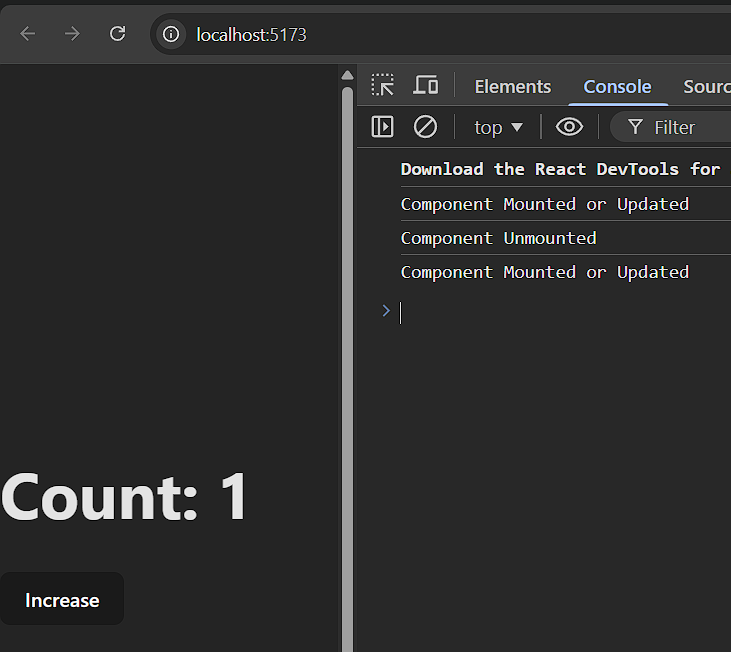

**TASK 2**

 **Explain and discuss its syntax, purpose, and how it manages state in functional components for the following hook:**
 * useState()
 * useEffect()

<br>

 **useSate():**

  * useState is used to manage state in functional components.
  * state means data that can change over time, such as:
    * counter values
    * input field text
    * toggle(true/false)
    * logged-in status

    Before hooks, state was only available in class components.
    With `useState`, functional components can also manage state.

**Syntax**
  
      const [state, setState] = useState(initialValue);

**Example**

      const [count, setCount] = useState(0);



**useEffect():**

* The `useEffect` Hook  allows you to perform side effects in functional components, such as data fetching, subscriptions, or manually changing the DOM. It unifies the functionality of class component lifecycle methods like `componentDidMount`, `componentDidUpdate`, and `componentWillUnmount`.


**Syntax**
```
useEffect(() => {
  /* side effect code here (setup) */
   return cleanupFunction;
  }, [dependencies]); //dependency array

```
* **Setup function:** This is where you put your effect's logic. React runs this function after the component renders and the DOM is updated.

* **Cleanup function:** An optional function you return from the setup function. It runs before the component unmounts, or before the effect runs again due to a dependency change, to clean up resources (e.g., stopping timers, removing event listeners).

* **Dependency array (optional):** This array controls when the effect re-runs. React compares the current dependencies to the previous ones after each render. If any dependency has changed, the effect runs.

**TASK 3**

**Explain the concept of custom hooks in React, Provide one example scenario of when and how custom hooks can be useful, and also provide the code.**

**Custom Hooks:**
 Custom Hooks are javascript functions that allow you to exrtact and reuse stateful logic across multiple functional components. They must be named starting with the word `use` and internally call buit-in hooks like `useState` or `useEffect`.

 **When and How Custom Hooks are useful:**

  A common and practical scenario is fectching data from and API in multiple parts of ab application. Instead of dublicating the data - fetchng, loading, and error - handling logic in every component, we can encapsulate it in single `useFetch` custom hook.


  **Example:**
  `useFetch.js`

  ```
import { useState, useEffect } from 'react';

// Defines a custom hook to fetch data
function useFetch(url) {
  const [data, setData] = useState(null);


  useEffect(() => {
    // Fetches data and updates state
    const fetchData = async () => {
      try {
        const response = await fetch(url);
        const result = await response.json();
        setData(result);
      } catch (err) {
        setError(err.message);
      }
    };
    fetchData();
  }, [url]);

  return { data };
}

  ```

**TASK 4**

**Explore ways to optimize performance in React using hooks**



**TASK 5**

**Implement a global state management system using the Context API and useContext hook. Create providers and consumers for different contexts.**


```
import { useState } from "react";
import "./App.css";
import { CurrencyContext } from "./context/CurrencyContext.js";
import Home from "./pages/Home.jsx";
import Routing from "./components/Routing.jsx";
import Layout from "./pages/MainLayout.jsx";
import MainLayout from "./pages/MainLayout.jsx";

function App() {
  const [currency, setCurrency] = useState('inr');
  const CurrencyContext = createContext();
  return (
    <>
      <CurrencyContext.Provider value={{ currency, setCurrency }}>
        <MainLayout />
      </CurrencyContext.Provider>
    </>
  );
}

export default App;

```
```
import { useContext, useState } from "react";
import { fetchCoinData } from "../../services/FetchCoinData";
import { useQuery } from "@tanstack/react-query";
import { CurrencyContext } from "../../context/CurrencyContext";
import CoinTable from "./CoinTable";
import { SearchContext } from "../../context/SearchContext";
import { FetchSearchCoin } from "../../services/FetchSearchCoin";
import { FetchCoinById } from "../../services/FetchCoinById";


const CoinTableContainer = () => {
    const [page, setPage] = useState(1);
    const { currency } = useContext(CurrencyContext); // consuming currency from context
    const { searchQuery } = useContext(SearchContext);
    const { data, isLoading, isError, error } = useQuery({
        queryKey: ["coins", page, currency, searchQuery],
        queryFn: async () => {
            // normal list
            if (!searchQuery) {
                return fetchCoinData(page, currency);
            }
            // search mode
            const ids = await FetchSearchCoin(searchQuery);
            if (ids.length === 0) return [];
            return FetchCoinById(ids, currency);
        },
        
        gcTime: 1000 * 60 * 2,
        staleTime: 1000 * 60,
    });
    console.log(data);
    return (
        <CoinTable
            data={data}
            currency={currency}
            page={page}
            setPage={setPage}
            isError={isError}
            isLoading={isLoading}
            error={error}
        />
    );
};

export default CoinTableContainer;
```
